# Hospital Locations on LA County Map
Visualizes 165 hospitals overlaid on the 272 LA County neighborhood polygons.

## Step 1 — Imports

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import pandas as pd
import numpy as np
from shapely.ops import unary_union

print("Ready.")

Ready.


## Step 2 — Load Data

In [2]:
la_county = gpd.read_file("../../data/la_county.geojson").set_crs("EPSG:4326", allow_override=True)
hospitals  = gpd.read_file("../../data/hospitals.geojson").set_crs("EPSG:4326", allow_override=True)

print(f"Neighborhoods : {len(la_county)}")
print(f"Hospitals     : {len(hospitals)}")
hospitals.head()

Neighborhoods : 272
Hospitals     : 165


,objectid,name,city,geometry
0,9,Verdugo Hills Hospital,Glendale,POINT (-118.21602 34.20453)
1,11,Barlow Respiratory Hospital - Los Angeles (Mai...,Los Angeles,POINT (-118.24831 34.07569)
2,20,Glendora Community Hospital,Glendora,POINT (-117.86507 34.12731)
3,25,Providence Little Company Of Mary Medical Cent...,Torrance,POINT (-118.35711 33.83863)
4,35,Glendale Memorial Hospital And Health Center,Glendale,POINT (-118.25744 34.12806)


## Step 3 — Spatial Join: Assign Each Hospital to a Neighborhood

Tags every hospital point with the neighborhood it falls inside.
Hospitals that fall outside all neighborhood polygons get `neighborhood = None`.

In [3]:
hospitals_joined = gpd.sjoin(
    hospitals,
    la_county[["name", "geometry"]],
    how="left",
    predicate="within"
).rename(columns={"name_right": "neighborhood"})

# Count hospitals per neighborhood
hosp_per_hood = (
    hospitals_joined.groupby("neighborhood")   # fix 1: was "city"
    .size()
    .reset_index(name="hospital_count")
)

la_county = la_county.merge(
    hosp_per_hood,
    left_on="name",         # fix 2: explicit left/right keys
    right_on="neighborhood",
    how="left"
)
la_county["hospital_count"] = la_county["hospital_count"].fillna(0).astype(int)

n_covered = (la_county["hospital_count"] > 0).sum()
n_none    = (la_county["hospital_count"] == 0).sum()
n_outside = hospitals_joined["neighborhood"].isna().sum()

print(f"Neighborhoods WITH at least 1 hospital : {n_covered}")
print(f"Neighborhoods with NO hospital         : {n_none}")
print(f"Hospitals outside named neighborhoods  : {n_outside}")

Neighborhoods WITH at least 1 hospital : 70
Neighborhoods with NO hospital         : 202
Hospitals outside named neighborhoods  : 3


## Step 4 — Map: Hospitals on LA County Neighborhoods

Neighborhoods are colored by hospital count.
Red dots = hospital locations.

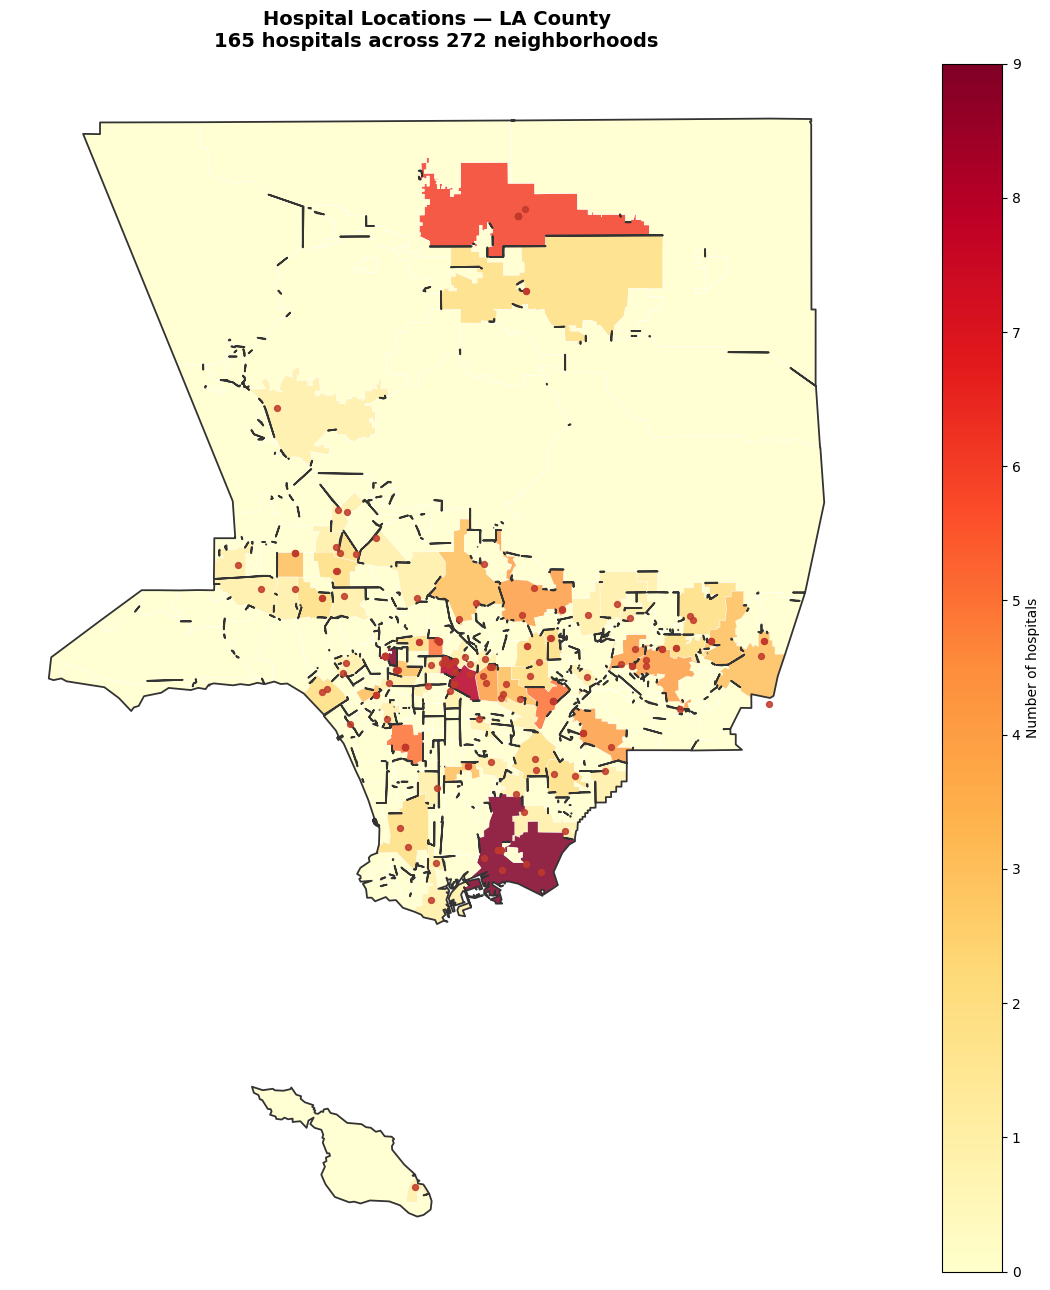

Saved: hospitals_la_county.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 13))

# ── Neighborhood choropleth ──
la_county.plot(
    column="hospital_count",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.85,
    legend=True,
    legend_kwds={
        "label": "Number of hospitals",   # fix 1: removed shrink/pad
    }
)

# ── County boundary outline ──
gpd.GeoSeries([unary_union(la_county.geometry)]).plot(
    ax=ax, facecolor="none", edgecolor="#333", linewidth=1.3
)

# ── Hospital points ──
hospitals.plot(
    ax=ax,
    color="#c0392b",
    markersize=18,
    alpha=0.85,
    zorder=5,
    label="Hospital"
)

# # ── Hospital name labels ──
# for i, row in hospitals.iterrows():
#     ax.annotate(
#         row["name"],
#         xy=(row.geometry.x, row.geometry.y),
#         xytext=(3, 3), textcoords="offset points",
#         fontsize=3.2, color="#1a1a1a", alpha=0.8,
#         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")],
#         zorder=6,
#     )

ax.set_title(
    f"Hospital Locations — LA County\n"          # fix 2: \n instead of raw newline
    f"{len(hospitals)} hospitals across {len(la_county)} neighborhoods",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("hospitals_la_county.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: hospitals_la_county.png")

## Step 5 — Hospital Density Map (hospitals per km²)

Normalizes hospital count by neighborhood area to show relative density
rather than raw count.

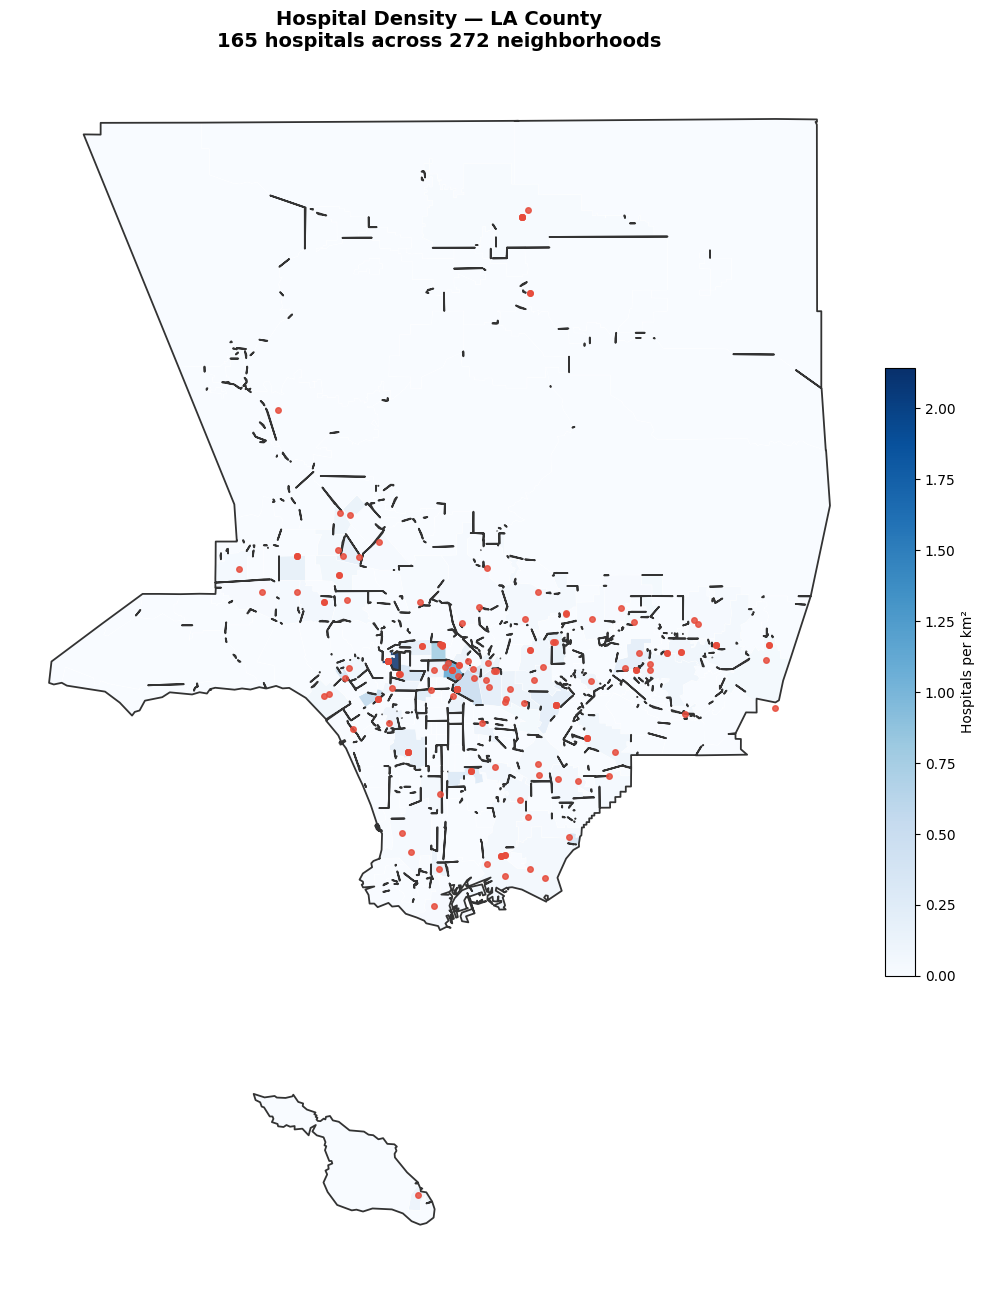

Saved: hospital_density_la_county.png


In [5]:
la_utm = la_county.to_crs("EPSG:32611")
la_county["area_km2"]       = (la_utm.geometry.area / 1e6).round(3)
la_county["density_per_km2"] = (
    la_county["hospital_count"] / la_county["area_km2"]
).round(5)

fig, ax = plt.subplots(figsize=(16, 13))

la_county.plot(
    column="density_per_km2",
    ax=ax,
    cmap="Blues",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.85,
    legend=True,
    legend_kwds={
        "label"  : "Hospitals per km²",
        "shrink" : 0.5,
        "pad"    : 0.01,
    }
)

gpd.GeoSeries([unary_union(la_county.geometry)]).plot(
    ax=ax, facecolor="none", edgecolor="#333", linewidth=1.3
)

hospitals.plot(
    ax=ax, color="#e74c3c", markersize=16,
    alpha=0.85, zorder=5
)

ax.set_title(
    f"Hospital Density — LA County\n"         # fix 2: \n instead of raw newline
    f"{len(hospitals)} hospitals across {len(la_county)} neighborhoods",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("hospital_density_la_county.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: hospital_density_la_county.png")

## Step 6 — Highlight Neighborhoods with No Hospitals

These are the neighborhoods with zero hospitals — potentially underserved
zones relevant to the disaster vulnerability analysis.

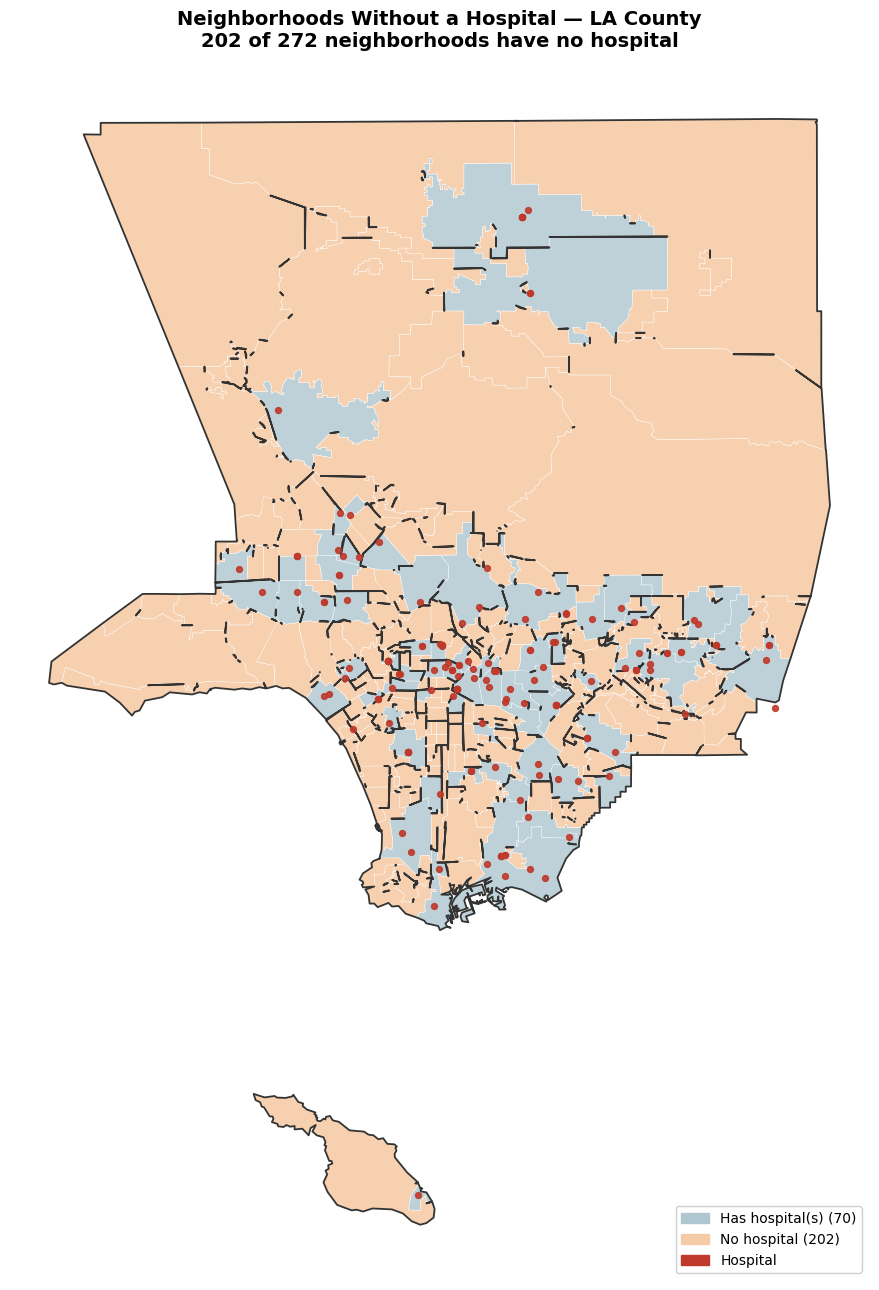

Saved: no_hospital_neighborhoods.png


In [6]:
no_hospital = la_county[la_county["hospital_count"] == 0].copy()
has_hospital = la_county[la_county["hospital_count"] > 0].copy()

fig, ax = plt.subplots(figsize=(16, 13))

has_hospital.plot(
    ax=ax, color="#aec6cf", edgecolor="white", linewidth=0.35, alpha=0.80
)
no_hospital.plot(
    ax=ax, color="#f5cba7", edgecolor="white", linewidth=0.35, alpha=0.90
)

gpd.GeoSeries([unary_union(la_county.geometry)]).plot(
    ax=ax, facecolor="none", edgecolor="#333", linewidth=1.3
)

hospitals.plot(
    ax=ax, color="#c0392b", markersize=18, alpha=0.90, zorder=5
)

patches = [
    mpatches.Patch(color="#aec6cf",
                   label=f"Has hospital(s) ({len(has_hospital)})"),
    mpatches.Patch(color="#f5cba7",
                   label=f"No hospital ({len(no_hospital)})"),
    mpatches.Patch(color="#c0392b", label="Hospital"),
]
ax.legend(handles=patches, fontsize=10, loc="lower right", framealpha=0.92)

ax.set_title(
    f"Neighborhoods Without a Hospital — LA County\n"         # fix 2: \n instead of raw newline
    f"{len(no_hospital)} of {len(la_county)} neighborhoods have no hospital",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("no_hospital_neighborhoods.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: no_hospital_neighborhoods.png")

## Step 7 — Summary Table

In [7]:
# Top neighborhoods by hospital count
top = (
    la_county[la_county["hospital_count"] > 0]
    [["name", "hospital_count", "area_km2", "density_per_km2"]]
    .sort_values("hospital_count", ascending=False)
    .reset_index(drop=True)
)
top.index += 1

print(f"Neighborhoods with hospitals: {len(top)}")
print(f"Total hospitals mapped      : {la_county['hospital_count'].sum()}")
print(f"Hospitals outside polygons  : {n_outside}")
print()
print("Top 20 neighborhoods by hospital count:")
top.head(20)

Neighborhoods with hospitals: 70
Total hospitals mapped      : 162
Hospitals outside polygons  : 3

Top 20 neighborhoods by hospital count:


,name,hospital_count,area_km2,density_per_km2
1,Long Beach,9,134.744,0.06679
2,Beverly Grove,9,4.199,2.14337
3,Westlake,8,6.920,1.15607
4,Downtown,8,14.969,0.53444
5,Lancaster,6,264.893,0.02265
6,Inglewood,5,23.459,0.21314
7,Montebello,5,21.757,0.22981
8,East Hollywood,5,6.160,0.81169
9,Boyle Heights,4,17.119,0.23366
10,Whittier,4,38.181,0.10476
